## Datos normales de train

Los detectores de anomalías se entrenan con ejemplos normales de train. Esto sigue la lógica habitual de estos métodos. Primero se aprende qué aspecto tiene el comportamiento normal y después se consideran anómalos los casos que se alejan de ese patrón.

En este notebook no se usan las etiquetas positivas para entrenar los detectores. Los fallos APS se reservan para evaluar si realmente aparecen como casos raros. Esta diferencia es importante respecto al modelado supervisado del notebook 02.

El preprocesamiento se ajusta con datos normales de train. Después se transforma test para evaluar el detector ya fijado. El umbral de anomalía también se calcula con scores de train. De esta forma, la evaluación final no se usa para calibrar el detector.

Esta sección no repite la selección del modelo principal. Solo prepara una lectura alternativa del problema, basada en rareza frente al comportamiento normal.

## Preparación

Esta celda carga las librerías necesarias para entrenar detectores de anomalías y evaluar sus resultados. También reutiliza funciones del proyecto para calcular métricas y coste.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_utils import *

RANDOM_STATE = 42
crear_carpetas(".")
sns.set_theme(style="whitegrid")

El entorno queda preparado para el análisis de anomalías. Los resultados se guardarán en artefactos para poder consultarlos después.


## Datos normales de train

Los detectores de anomalías se entrenan con ejemplos normales de train. El objetivo es aprender cómo se comporta el sistema cuando no hay fallo APS y después marcar como raros los casos que se alejan de ese patrón.

Este enfoque es diferente al modelado supervisado. Aquí no se entrena al detector con ejemplos positivos. La clase positiva solo se usa después para evaluar si las anomalías detectadas coinciden con fallos APS reales.

El preprocesamiento se ajusta con datos normales de train. Después se aplica la misma transformación a test para poder evaluar. El umbral de anomalía también se calcula con los scores obtenidos en train. Así, el detector queda fijado antes de medir su comportamiento final.

Esta sección no busca optimizar el modelo principal, sino comprobar si la rareza respecto al comportamiento normal aporta información útil.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

train_df = cargar_csv("data/processed/train.csv")
test_df = cargar_csv("data/processed/test.csv")
X_train, y_train = separar_x_y(train_df)
X_test, y_test = separar_x_y(test_df)
normal_train = X_train[y_train == 0]
prep = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
X_normal = prep.fit_transform(normal_train)
X_test_s = prep.transform(X_test)
contamination = float(y_train.mean())

# El umbral se fija con scores de train normal.
# Test solo se usa para evaluar al final.
def eval_anomaly(nombre, train_scores, test_scores):
    limite = np.percentile(train_scores, 100 * (1 - contamination))
    y_pred = (test_scores >= limite).astype(int)
    out = calcular_metricas(y_test, y_pred, test_scores)
    out["modelo"] = nombre
    out["threshold_from_train"] = float(limite)
    return out

La función de evaluación mantiene el protocolo correcto. Primero calcula el umbral con scores de train y con la contaminación estimada en train. Después aplica ese umbral a test.

## Detectores ejecutados

Esta sección entrena tres detectores de anomalías. **Isolation Forest** busca observaciones fáciles de aislar mediante particiones aleatorias. **Local Outlier Factor** compara la densidad local de cada punto con la de sus vecinos. **One-Class SVM** aprende una frontera alrededor de los datos normales y marca como raros los puntos que quedan fuera.

Los tres métodos representan formas distintas de definir anomalía. Esto permite comparar si el fallo APS se detecta mejor como aislamiento, como baja densidad local o como separación respecto a una frontera aprendida sobre casos normales.

Por coste computacional y estabilidad del entorno, **Local Outlier Factor** y **One-Class SVM** se entrenan con una muestra de casos normales de train. Esto mantiene el análisis manejable y evita que el notebook dependa de técnicas que no ejecutan de forma estable. Todas las muestras usadas salen de train.

El resultado debe interpretarse como análisis secundario. Si un detector obtiene buen recall o bajo coste, eso no lo convierte automáticamente en el modelo final. Sirve para entender otra forma de detectar fallos y para discutir posibles usos auxiliares.

In [ ]:
rows = []
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(X_normal.shape[0], size=min(5000, X_normal.shape[0]), replace=False)
X_normal_sample = X_normal[idx]

iso = IsolationForest(n_estimators=100, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
iso.fit(X_normal)
train_scores_iso = -iso.score_samples(X_normal)
test_scores_iso = -iso.score_samples(X_test_s)
rows.append(eval_anomaly("isolation_forest", train_scores_iso, test_scores_iso))

lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True, algorithm="ball_tree", n_jobs=1)
lof.fit(X_normal_sample)
train_scores_lof = -lof.score_samples(X_normal_sample)
test_scores_lof = -lof.score_samples(X_test_s)
rows.append(eval_anomaly("local_outlier_factor_sample", train_scores_lof, test_scores_lof))

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=contamination)
ocsvm.fit(X_normal_sample)
train_scores_ocsvm = -ocsvm.score_samples(X_normal_sample)
test_scores_ocsvm = -ocsvm.score_samples(X_test_s)
rows.append(eval_anomaly("one_class_svm_sample", train_scores_ocsvm, test_scores_ocsvm))


anomaly_results = pd.DataFrame(rows)
anomaly_results.to_csv("artifacts/metrics/anomaly_results.csv", index=False)
anomaly_results

,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,tn,fp,fn,tp,coste,modelo,threshold_from_train
0,0.978500,0.841941,0.531440,0.698667,0.603687,0.984704,0.568394,15394,231,113,262,58810,isolation_forest,0.616964
1,0.962625,0.581355,0.189415,0.181333,0.185286,0.904993,0.145556,15334,291,307,68,156410,local_outlier_factor_sample,4.526699
2,0.961000,0.930581,0.365114,0.898667,0.519260,0.969693,0.589215,15039,586,38,337,24860,one_class_svm_sample,-0.605025


La tabla muestra comportamientos muy distintos entre los tres detectores.

**Isolation Forest** ofrece el resultado más equilibrado. Detecta **262** de los **375** fallos APS de test, con un **recall positivo cercano a 0.699**. Genera **231 falsos positivos** y deja **113 falsos negativos**, lo que produce un coste de **58810**. Es una opción razonable si se busca una alerta secundaria con un equilibrio moderado entre detección y falsas alarmas.

**Local Outlier Factor** es el detector menos útil en este dataset. Solo detecta **68** fallos APS y deja escapar **307**. Su **recall positivo es cercano a 0.181** y el coste sube hasta **156410**. Aunque su ROC-AUC es relativamente alto, su comportamiento con el umbral fijado desde train no es bueno para el objetivo operativo. En la práctica, deja demasiados fallos APS sin detectar.

**One-Class SVM** tiene el perfil más agresivo. Detecta **337** de los **375** fallos APS y reduce los falsos negativos a **38**. Esto explica su **recall positivo cercano a 0.899** y su coste de **24860**, el más bajo de la tabla. El precio es que genera **586 falsos positivos**, por lo que muchas más revisiones serían innecesarias.

La comparación es útil porque muestra un trade-off claro. **Isolation Forest** es más equilibrado. **One-Class SVM** prioriza detectar fallos aunque aumenten las falsas alarmas. **Local Outlier Factor** no resulta competitivo en esta configuración.

En un contexto de mantenimiento, **One-Class SVM** podría ser interesante como sistema auxiliar de alerta si el objetivo fuese reducir al máximo los fallos no detectados. Aun así, no sustituye al modelo supervisado principal, porque su precisión es baja y genera muchas falsas alarmas. Su valor está en complementar la discusión sobre coste y riesgo operativo.

## Figura de scores

Esta figura muestra la distribución de los scores de anomalía de **Isolation Forest** en test. Un score más alto indica que la observación se parece menos al comportamiento normal aprendido por el detector.

La visualización permite comprobar si los casos positivos tienden a recibir scores más altos que los negativos. Esto ayuda a interpretar el detector de forma más intuitiva que una tabla de métricas. El umbral ya fue fijado antes con los scores de train, por lo que esta figura solo se usa como análisis visual.

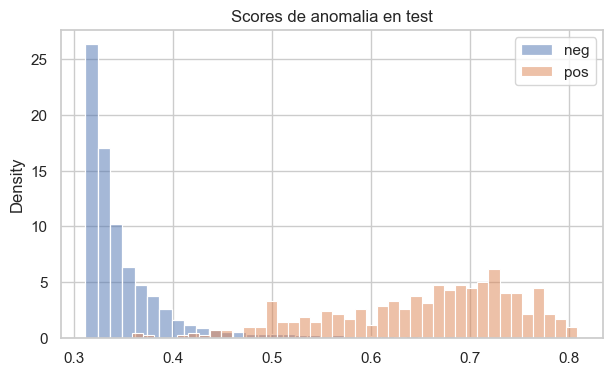

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(test_scores_iso[y_test == 0], bins=40, label="neg", ax=ax, stat="density", alpha=0.5)
sns.histplot(test_scores_iso[y_test == 1], bins=40, label="pos", ax=ax, stat="density", alpha=0.5)
ax.set_title("Scores de anomalia en test")
ax.legend()
guardar_figura(fig, "artifacts/figures/anomaly_scores_isolation_forest.png")
plt.show()

La figura muestra una separación bastante clara entre las dos clases. Los casos negativos se concentran sobre todo en scores bajos, alrededor de **0.32** a **0.40**. En cambio, muchos casos positivos aparecen desplazados hacia scores más altos, especialmente entre **0.55** y **0.80**.

Esto indica que **Isolation Forest** sí captura parte de la rareza asociada a los fallos APS. Los positivos tienden a parecer menos normales que los negativos, lo que explica que el detector consiga un recall razonable.

Aun así, las distribuciones no están completamente separadas. Hay una zona intermedia donde algunos positivos y negativos se mezclan. Esto explica que el detector siga cometiendo falsos positivos y falsos negativos. Por tanto, la figura apoya el análisis de anomalías, pero no convierte este detector en sustituto del modelo supervisado.

## Interpretación del análisis de anomalías

El análisis de anomalías aporta una lectura complementaria del problema APS. Los detectores entrenados con casos normales permiten estudiar si los fallos se comportan como observaciones raras respecto al funcionamiento habitual del camión.

Los resultados muestran que esta idea tiene sentido, pero con matices. **Isolation Forest** ofrece un comportamiento equilibrado y la figura de scores muestra que muchos positivos reciben valores más altos que los negativos. **One-Class SVM** reduce más los falsos negativos y obtiene el menor coste, pero genera muchas más falsas alarmas. **Local Outlier Factor** es el menos útil en esta configuración porque deja escapar demasiados fallos APS.

La conclusión debe ser prudente. Los detectores de anomalías pueden servir como sistema auxiliar de alerta, especialmente cuando se quiere reducir el número de fallos no detectados. Sin embargo, no aprovechan toda la información disponible en las etiquetas y no sustituyen al modelo supervisado principal.

Si se quisiera convertir anomalías en una estrategia principal, habría que diseñar un experimento específico. Ese experimento tendría que seleccionar detector, hiperparámetros y umbral dentro de train, con una métrica definida antes de mirar test.